# Model Evaluation

This notebook evaluates the selected final model from Phase 7.

The evaluation focuses on classification performance using the held-out test dataset. No model retraining is performed in this notebook.

## 8.1 Classification Evaluation

The selected Logistic Regression model is evaluated using standard classification metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Classification Report

In [1]:
import sys
from pathlib import Path

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

PROJECT_ROOT_81 = Path.cwd().parent

if str(PROJECT_ROOT_81) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_81))

from backend.src.ml.preprocessing_pipeline import build_preprocessing_pipeline

In [2]:
import joblib

MODEL_PATH_81 = (
    PROJECT_ROOT_81
    / "backend"
    / "artifacts"
    / "models"
    / "logistic_regression_final.joblib"
)

final_model_81 = joblib.load(MODEL_PATH_81)

print("Final model loaded successfully.")
print("Model type:", type(final_model_81).__name__)

Final model loaded successfully.
Model type: Pipeline


In [3]:
from sklearn.model_selection import train_test_split

DATA_PATH_81 = (
    PROJECT_ROOT_81
    / "data"
    / "raw"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df_81 = pd.read_csv(DATA_PATH_81)

X_81 = df_81.drop(columns=["customerID", "Churn"])

y_81 = df_81["Churn"].map({
    "No": 0,
    "Yes": 1
})

X_train_81, X_test_81, y_train_81, y_test_81 = train_test_split(
    X_81,
    y_81,
    test_size=0.20,
    random_state=42,
    stratify=y_81
)

print("Evaluation dataset prepared.")
print("Test shape:", X_test_81.shape)
print("Test target shape:", y_test_81.shape)

Evaluation dataset prepared.
Test shape: (1409, 19)
Test target shape: (1409,)


In [4]:
y_pred_81 = final_model_81.predict(X_test_81)
y_prob_81 = final_model_81.predict_proba(X_test_81)[:, 1]

metrics_81 = {
    "Accuracy": accuracy_score(y_test_81, y_pred_81),
    "Precision": precision_score(y_test_81, y_pred_81),
    "Recall": recall_score(y_test_81, y_pred_81),
    "F1 Score": f1_score(y_test_81, y_pred_81),
    "ROC-AUC": roc_auc_score(y_test_81, y_prob_81)
}

print("=" * 60)
print("FINAL MODEL CLASSIFICATION METRICS")
print("=" * 60)

for metric, score in metrics_81.items():
    print(f"{metric:<10}: {score:.4f}")

FINAL MODEL CLASSIFICATION METRICS
Accuracy  : 0.7999
Precision : 0.6554
Recall    : 0.5187
F1 Score  : 0.5791
ROC-AUC   : 0.8424


In [5]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_81,
        y_pred_81,
        target_names=["No Churn", "Churn"]
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 8.2 Confusion Matrix & Error Analysis

The confusion matrix is used to examine correct and incorrect predictions for both churn classes.

The analysis focuses particularly on false negatives, where customers who actually churned were predicted as non-churn.

In [6]:
from sklearn.metrics import confusion_matrix

confusion_matrix_82 = confusion_matrix(
    y_test_81,
    y_pred_81
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(confusion_matrix_82)

tn_82, fp_82, fn_82, tp_82 = confusion_matrix_82.ravel()

print("\nTrue Negatives :", tn_82)
print("False Positives:", fp_82)
print("False Negatives:", fn_82)
print("True Positives :", tp_82)

CONFUSION MATRIX
[[933 102]
 [180 194]]

True Negatives : 933
False Positives: 102
False Negatives: 180
True Positives : 194


In [7]:
print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(f"False negatives: {fn_82}")
print(f"False positives: {fp_82}")
print(f"Missed churn rate: {fn_82 / (fn_82 + tp_82):.4f}")
print(f"False positive rate: {fp_82 / (tn_82 + fp_82):.4f}")

ERROR ANALYSIS
False negatives: 180
False positives: 102
Missed churn rate: 0.4813
False positive rate: 0.0986


## 8.3 ROC-AUC & Precision-Recall Analysis

ROC-AUC and Precision-Recall curves are used to evaluate the model's discrimination capability across different classification thresholds.

ROC-AUC measures the model's ability to distinguish between churn and non-churn customers.

The Precision-Recall curve provides additional insight into performance for the churn class, particularly when identifying positive cases is important.

In [8]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

roc_auc_83 = roc_auc_score(
    y_test_81,
    y_prob_81
)

fpr_83, tpr_83, _ = roc_curve(
    y_test_81,
    y_prob_81
)

precision_83, recall_83, _ = precision_recall_curve(
    y_test_81,
    y_prob_81
)

average_precision_83 = average_precision_score(
    y_test_81,
    y_prob_81
)

print("=" * 60)
print("ROC-AUC & PRECISION-RECALL ANALYSIS")
print("=" * 60)

print(f"ROC-AUC: {roc_auc_83:.4f}")
print(f"Average Precision: {average_precision_83:.4f}")

ROC-AUC & PRECISION-RECALL ANALYSIS
ROC-AUC: 0.8424
Average Precision: 0.6367


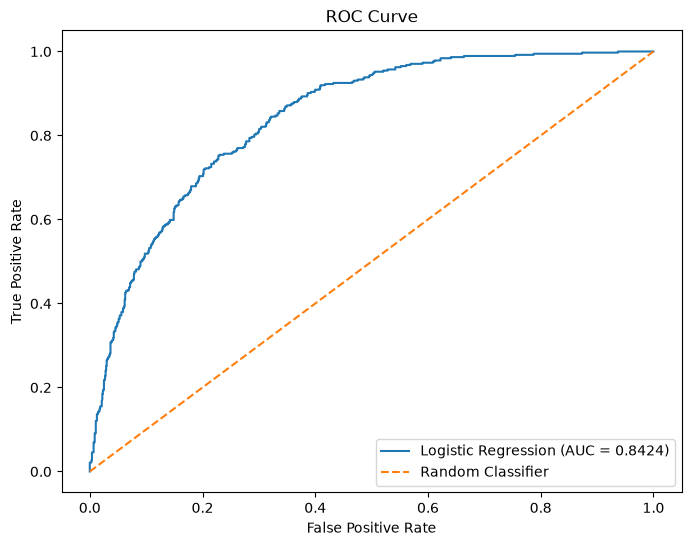

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_83,
    tpr_83,
    label=f"Logistic Regression (AUC = {roc_auc_83:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

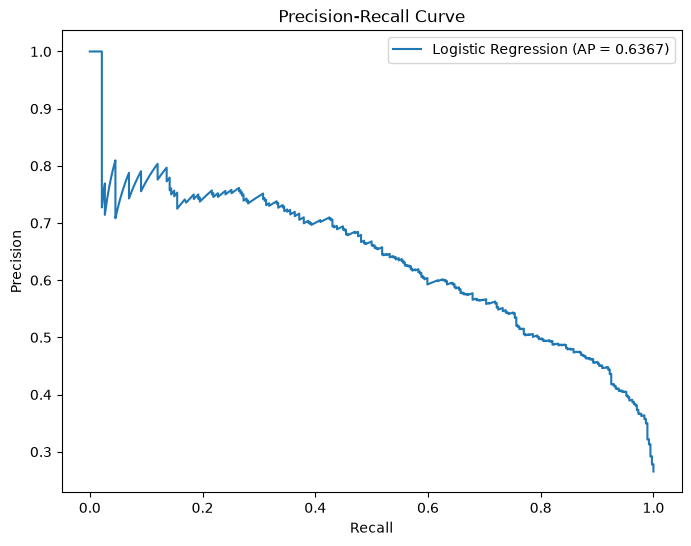

In [10]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_83,
    precision_83,
    label=f"Logistic Regression (AP = {average_precision_83:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## 8.4 SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to explain the predictions of the selected Logistic Regression model.

The analysis identifies which processed features contribute most strongly toward churn and non-churn predictions.

Positive SHAP values indicate contributions toward the churn class, while negative values indicate contributions toward the non-churn class.

In [11]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [13]:
preprocessing_84 = final_model_81.named_steps["preprocessing"]
classifier_84 = final_model_81.named_steps["classifier"]

X_train_transformed_84 = preprocessing_84.transform(
    X_train_81
)

X_test_transformed_84 = preprocessing_84.transform(
    X_test_81
)

feature_names_84 = (
    preprocessing_84
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

print("Training matrix:", X_train_transformed_84.shape)
print("Testing matrix:", X_test_transformed_84.shape)
print("Feature names:", len(feature_names_84))

Training matrix: (5634, 34)
Testing matrix: (1409, 34)
Feature names: 34


In [14]:
explainer_84 = shap.LinearExplainer(
    classifier_84,
    X_train_transformed_84
)

shap_values_84 = explainer_84(
    X_test_transformed_84
)

print("SHAP explanation generated successfully.")
print("SHAP values shape:", shap_values_84.values.shape)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


SHAP explanation generated successfully.
SHAP values shape: (1409, 34)


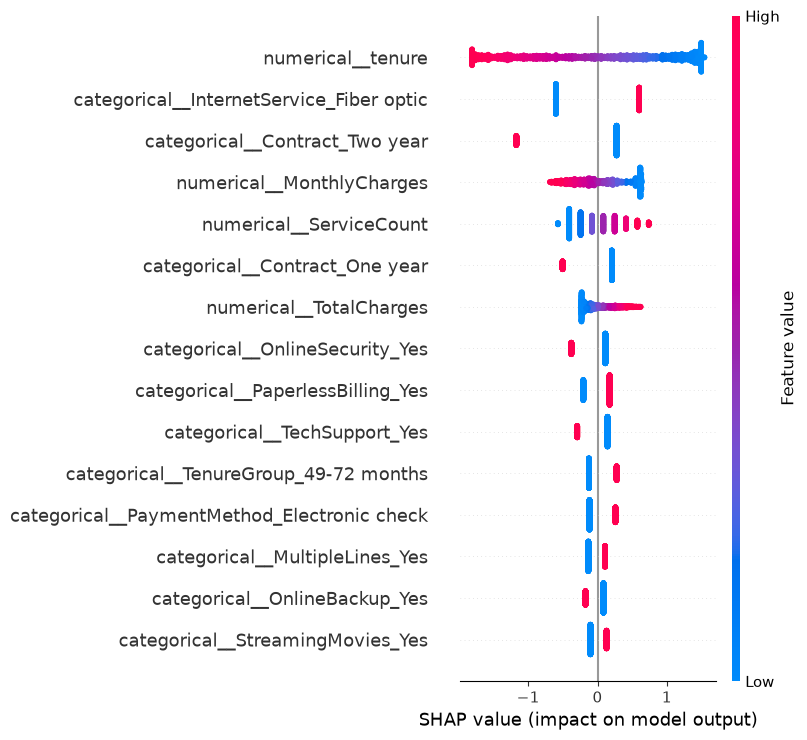

In [15]:
shap.summary_plot(
    shap_values_84,
    X_test_transformed_84,
    feature_names=feature_names_84,
    max_display=15,
    show=True
)